# Xu & Froment (1989) kinetics

Arrhenius plot of the rate coefficients $k_1, k_2, k_3$ (compare Fig. 9 of Part I) and the intrinsic
rates $r_1, r_2, r_3$ at 25 bar for an un-reacted feed CH$_4$:H$_2$O:H$_2$ = 1:3:0.1, using the
parameters in `data/kinetics/xu_froment_1989.yaml` and equilibrium constants from Cantera (GRI-Mech 3.0).
The table at the end compares Cantera-based and empirical (Twigg / Elnashaie) equilibrium constants.

k_ref: {1: 0.0001842, 2: 7.558, 3: 2.193e-05}
E [kJ/mol]: {1: 240.1, 2: 67.13, 3: 243.9}
fresh-catalyst factor: 2.246


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig01_kinetics.png


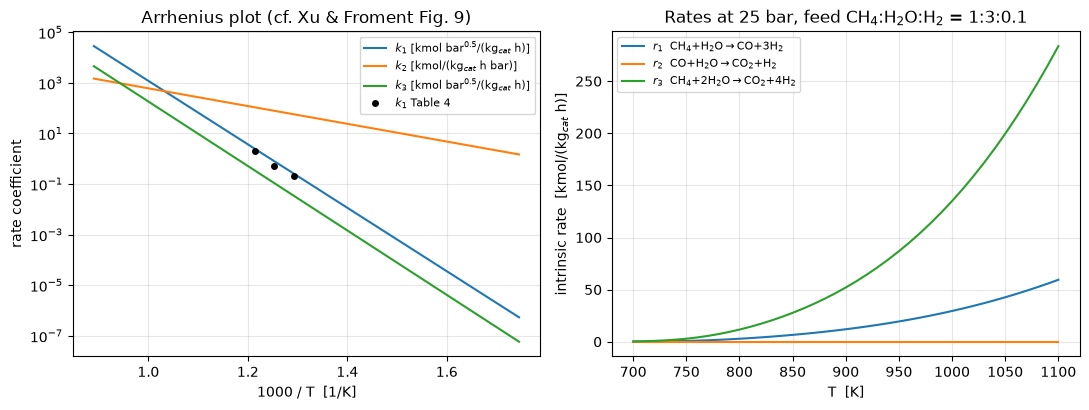

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdt import kinetics as kin

prm = kin.load_params()
print("k_ref:", prm.k_ref)
print("E [kJ/mol]:", prm.E)
print("fresh-catalyst factor:", prm.fresh_factor)

T_arr = np.linspace(573.0, 1123.0, 60)          # K, covers Table 4 range and up to reformer outlet
k1, k2, k3 = prm.arrhenius(T_arr)

P_bar = 25.0
feed = {"CH4": 1.0, "H2O": 3.0, "H2": 0.1}
tot = sum(feed.values())
p = {s: P_bar * feed.get(s, 0.0) / tot for s in kin.SPECIES}

T_r = np.linspace(700.0, 1100.0, 41)
r1, r2, r3 = kin.rates(T_r, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
x = 1000.0 / T_arr
ax1.semilogy(x, k1, label=r"$k_1$ [kmol bar$^{0.5}$/(kg$_{cat}$ h)]")
ax1.semilogy(x, k2, label=r"$k_2$ [kmol/(kg$_{cat}$ h bar)]")
ax1.semilogy(x, k3, label=r"$k_3$ [kmol bar$^{0.5}$/(kg$_{cat}$ h)]")
# Table 4 per-temperature estimates (Part I, p. 93) for reference
ax1.semilogy(1000.0 / np.array([773.0, 798.0, 823.0]), [0.2088, 0.5254, 2.069], "ko", ms=4, label=r"$k_1$ Table 4")
ax1.set_xlabel("1000 / T  [1/K]")
ax1.set_ylabel("rate coefficient")
ax1.set_title("Arrhenius plot (cf. Xu & Froment Fig. 9)")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(fontsize=8)

ax2.plot(T_r, r1, label=r"$r_1$  CH$_4$+H$_2$O$\to$CO+3H$_2$")
ax2.plot(T_r, r2, label=r"$r_2$  CO+H$_2$O$\to$CO$_2$+H$_2$")
ax2.plot(T_r, r3, label=r"$r_3$  CH$_4$+2H$_2$O$\to$CO$_2$+4H$_2$")
ax2.set_xlabel("T  [K]")
ax2.set_ylabel(r"intrinsic rate  [kmol/(kg$_{cat}$ h)]")
ax2.set_title("Rates at 25 bar, feed CH$_4$:H$_2$O:H$_2$ = 1:3:0.1")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)
fig.tight_layout()

out = Path("..") / "paper" / "figures" / "fig01_kinetics.png"
fig.savefig(out, dpi=150)
print("saved", out.resolve())
plt.show()


In [2]:
T_tab = np.arange(800.0, 1101.0, 50.0)
K1c, K2c, K3c = kin.equilibrium_constants_cantera(T_tab)
K1e, K2e, K3e = kin.equilibrium_constants_empirical(T_tab)
df = pd.DataFrame({
    "T [K]": T_tab,
    "K1 Cantera [bar^2]": K1c, "K1 empirical": K1e, "K1 dev %": 100 * (K1c / K1e - 1),
    "K2 Cantera [-]": K2c, "K2 empirical": K2e, "K2 dev %": 100 * (K2c / K2e - 1),
    "K3 Cantera [bar^2]": K3c, "K3 empirical": K3e, "K3 dev %": 100 * (K3c / K3e - 1),
}).set_index("T [K]")
pd.set_option("display.width", 200)
print(df.round(4).to_string())


        K1 Cantera [bar^2]  K1 empirical  K1 dev %  K2 Cantera [-]  K2 empirical  K2 dev %  K3 Cantera [bar^2]  K3 empirical  K3 dev %
T [K]                                                                                                                                 
800.0               0.0326        0.0326    0.1245          4.2198        4.3232   -2.3929              0.1377        0.1409   -2.2714
850.0               0.2339        0.2344   -0.2112          3.0538        3.1282   -2.3806              0.7143        0.7333   -2.5868
900.0               1.3553        1.3538    0.1133          2.3002        2.3464   -1.9693              3.1175        3.1765   -1.8582
950.0               6.5584        6.5006    0.8894          1.7916        1.8141   -1.2409             11.7499       11.7926   -0.3626
1000.0             27.2053       26.6823    1.9600          1.4354        1.4391   -0.2583             39.0493       38.3978    1.6967
1050.0             98.8034       95.7384    3.2015     